In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[29.56169666]
-1.8560995713242188


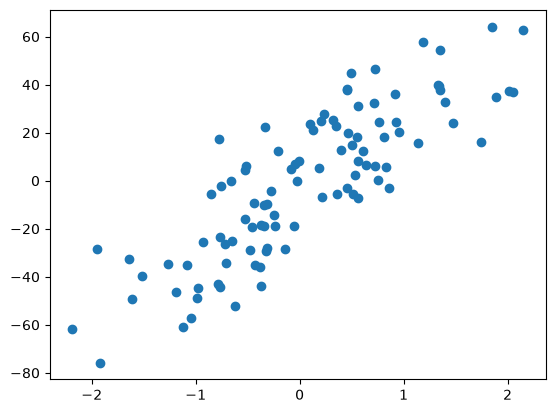

In [10]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

c:\Users\nkuma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)


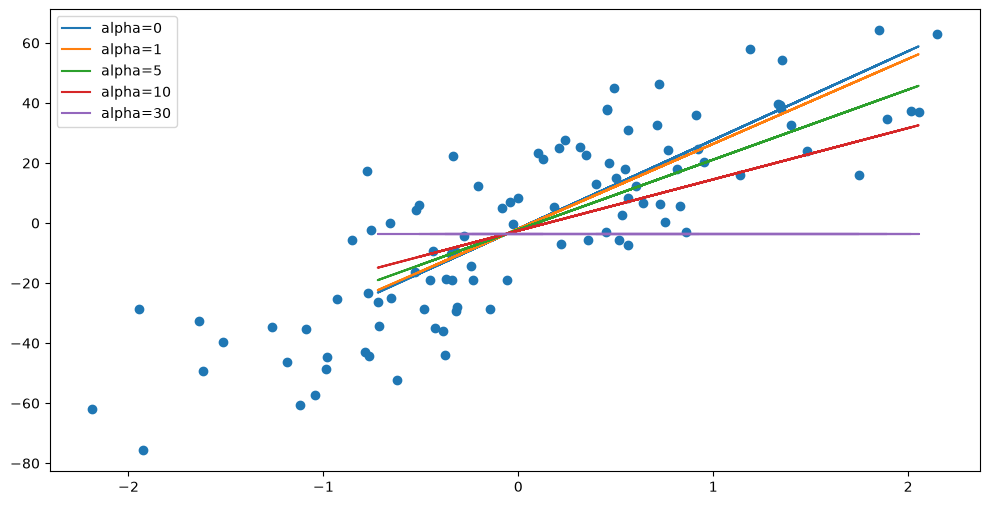

In [11]:
alphas = [0,1,5,10,30]

plt.figure(figsize=(12,6))
plt.scatter(X,y)

for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i))
plt.legend()
plt.show()

c:\Users\nkuma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\nkuma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.919743e+06, tolerance: 9.560e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\nkuma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You migh

<function matplotlib.pyplot.show(close=None, block=None)>

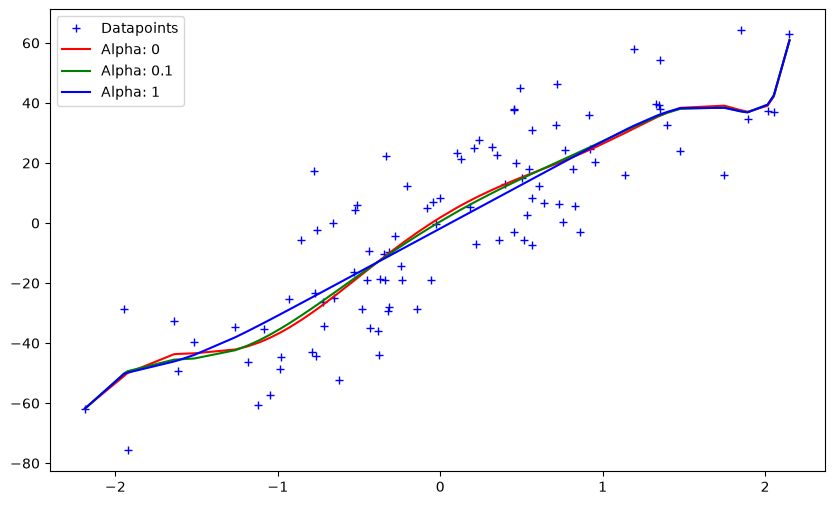

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(X, y, alpha):
    model = Pipeline([
        ('poly_feats',PolynomialFeatures(degree=16)),
        ('ridge',Lasso(alpha=alpha))
    ])
    model.fit(X,y)
    return model.predict(X)

alphas = [0,0.1,1]
cs = ['r','g','b']

plt.figure(figsize=(10,6))
plt.plot(X,y,'b+',label='Datapoints')

for alpha, c in zip(alphas,cs):
    preds = get_preds_ridge(X,y,alpha)

    plt.plot(sorted(X[:, 0]), preds[np.argsort(X[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show